In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

np.random.seed(42)
num_samples = 100

X = pd.DataFrame({
    'study_hours': np.random.normal(5, 2, num_samples).clip(1, 10),
    'attendance': np.random.randint(70, 100, num_samples),
    'extracurricular': np.random.randint(0, 2, num_samples),
    'prior_grades': np.random.normal(70, 10, num_samples).clip(40, 95)
})

y = ((X['study_hours'] * 5 + X['prior_grades'] * 0.5 + np.random.normal(0, 5, num_samples)) > 80).astype(int)

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,study_hours,attendance,extracurricular,prior_grades
0,5.993428,78,1,95.000000
1,4.723471,99,1,69.688132
2,6.295377,74,1,69.884167
3,8.046060,70,0,71.905987
4,4.531693,88,1,76.069757



Target (y) head:


,0
0,0
1,0
2,0
3,0
4,0


In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (70, 4)
Testing features shape: (30, 4)
Training target shape: (70,)
Testing target shape: (30,)



Training Decision Tree with max_depth=3
Accuracy for max_depth=3: 0.9667


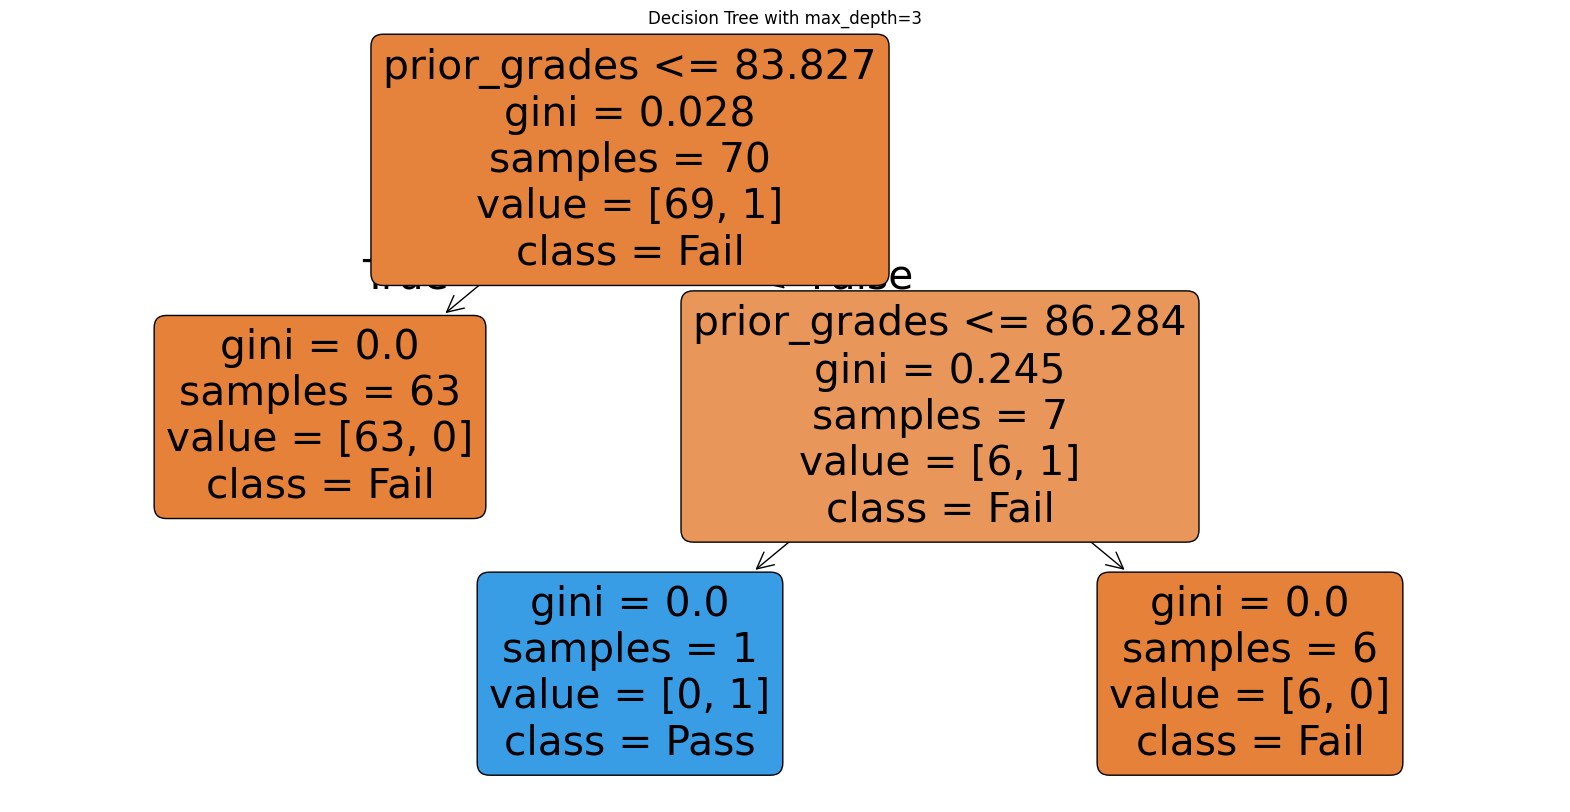


Training Decision Tree with max_depth=4
Accuracy for max_depth=4: 0.9667

Training Decision Tree with max_depth=5
Accuracy for max_depth=5: 0.9667


In [3]:
depths = [3, 4, 5]
results = {}

for depth in depths:
    print(f"\nTraining Decision Tree with max_depth={depth}")
    dt_classifier = DecisionTreeClassifier(max_depth=depth, random_state=42)

    dt_classifier.fit(X_train, y_train)

    y_pred = dt_classifier.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    results[depth] = accuracy

    print(f"Accuracy for max_depth={depth}: {accuracy:.4f}")

    if depth == 3:
        plt.figure(figsize=(20,10))
        plot_tree(dt_classifier, feature_names=X.columns.tolist(), class_names=['Fail', 'Pass'], filled=True, rounded=True)
        plt.title(f"Decision Tree with max_depth={depth}")
        plt.show()


Comparative Analysis of Decision Tree Model Performance:
Max Depth: 3, Accuracy: 0.9667
Max Depth: 4, Accuracy: 0.9667
Max Depth: 5, Accuracy: 0.9667


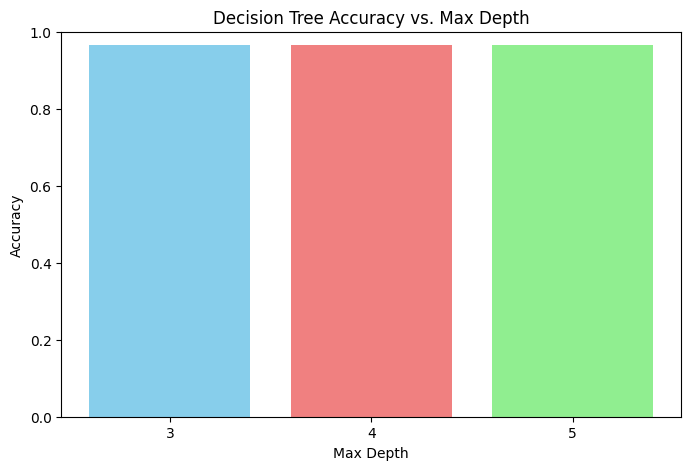


The best performing model has a max_depth of 3 with an accuracy of 0.9667.


In [4]:
print("\nComparative Analysis of Decision Tree Model Performance:")
for depth, accuracy in results.items():
    print(f"Max Depth: {depth}, Accuracy: {accuracy:.4f}")

plt.figure(figsize=(8, 5))
plt.bar([str(d) for d in results.keys()], results.values(), color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs. Max Depth")
plt.ylim(0, 1)
plt.show()

best_depth = max(results, key=results.get)
best_accuracy = results[best_depth]
print(f"\nThe best performing model has a max_depth of {best_depth} with an accuracy of {best_accuracy:.4f}.")

Demonstrating Linear Regression in the Electronics Industry (Component Pricing)

Sample Data Head:


,Manufacturing_Cost,Quality_Score,Price
0,57.450712,65.846293,103.652938
1,47.926035,75.793547,98.211939
2,59.715328,76.572855,115.360077
3,72.845448,71.977227,128.672161
4,46.487699,78.387143,88.090464



Training features shape: (70, 2)
Testing features shape: (30, 2)

Linear Regression Model Trained.
Coefficients: [1.25921858 0.53228422]
Intercept: -5.4310019854660965

Model Evaluation:
Mean Squared Error (MSE): 24.80
R-squared (R2): 0.90


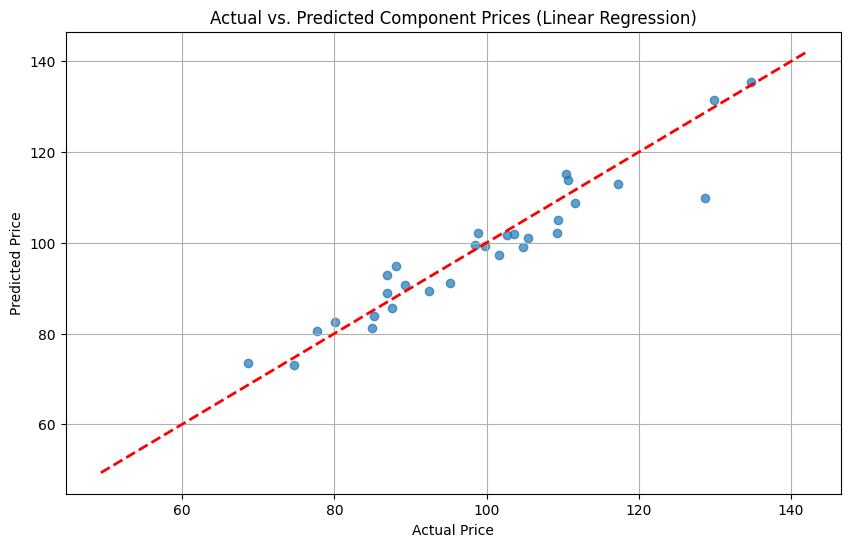


Example: A component with Manufacturing Cost $60.00 and Quality Score 85 is predicted to cost $115.37.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Demonstrating Linear Regression in the Electronics Industry (Component Pricing)")

np.random.seed(42)
num_components = 100

manufacturing_cost = np.random.normal(50, 15, num_components)
quality_score = np.random.normal(80, 10, num_components)

price = 1.2 * manufacturing_cost + 0.5 * quality_score + np.random.normal(0, 5, num_components)

data = pd.DataFrame({
    'Manufacturing_Cost': manufacturing_cost,
    'Quality_Score': quality_score,
    'Price': price
})

print("\nSample Data Head:")
display(data.head())

X = data[['Manufacturing_Cost', 'Quality_Score']]
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

model = LinearRegression()
model.fit(X_train, y_train)

print("\nLinear Regression Model Trained.")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted Component Prices (Linear Regression)")
plt.grid(True)
plt.show()

example_cost = 60
example_quality = 85
example_component = pd.DataFrame([[example_cost, example_quality]], columns=['Manufacturing_Cost', 'Quality_Score'])
predicted_price = model.predict(example_component)[0]
print(f"\nExample: A component with Manufacturing Cost ${example_cost:.2f} and Quality Score {example_quality} is predicted to cost ${predicted_price:.2f}.")